In [63]:
import os
import re
import json
import time
import asyncio
import boto3
from typing import Optional, Dict, Any, List
from pydantic import BaseModel, Field
from dotenv import load_dotenv

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

# Optional: Resolves potential event loop conflicts in older Jupyter versions
import nest_asyncio
nest_asyncio.apply()

load_dotenv()

# --- 1. Structured Output Models ---
class DiscoveryScriptOutput(BaseModel):
    discovery_script: str = Field(
        ...,
        description=(
            "A safe, read-only bash script designed to locate the target component installation. "
            "CRITICAL PROTOCOLS:\n"
            "1. DO NOT use the 'jq' command tool or external JSON libraries anywhere in the script.\n"
            "2. DO NOT define or invoke custom bash functions (e.g., do not use functions like 'add_location()').\n"
            "3. Collect discovered paths using standard loops (e.g., 'while read -r line') and manually format "
            "the stdout output into JSON using native 'printf'.\n"
            "4. Do not wrap the script inside markdown blocks."
        )
    )
    
# --- 2. State Specification ---
class DiscoveryAgentState(BaseModel):
    issue_description_raw: str
    parsed_issue: Dict[str, Any] = {}
    instance_id: str = ""
    component_name: str = ""
    
    # Script & Execution Tracking
    discovery_script: str = ""
    stdout: str = ""
    stderr: str = ""
    status: str = ""
    
    # Retry Loop Indicators
    retry_count: int = 0
    max_retries: int = 3
    
    # Final Extracted Architecture Result
    discovery_result: Optional[Dict[str, Any]] = None
    active_pids: list = []
    target_jars: list = []
    config_files: list = []

# --- 3. Functional Graph Nodes ---
async def parse_input_node(state: DiscoveryAgentState) -> Dict[str, Any]:
    """Safely cleans and parses scanner payloads containing unquoted JavaScript tokens like NaN."""
    raw_str = state.issue_description_raw
    # Sanitize naked NaN tokens to valid JSON null entries
    sanitized_str = re.sub(r'\bNaN\b', 'null', raw_str)
    parsed_json = json.loads(sanitized_str)
    
    return {
        "parsed_issue": parsed_json,
        "component_name": parsed_json.get("component", "unknown")
    }

async def generate_discovery_script_node(state: DiscoveryAgentState) -> Dict[str, Any]:
    """Generates an explicit OS/Language/Binary path discovery shell pipeline without external dependencies."""
    llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0).with_structured_output(DiscoveryScriptOutput)
    
    system_prompt = (
        "You are an elite DevSecOps automation tool. Your singular task is to write a standalone, "
        "safe, read-only bash script that discovers where and how a specific component is installed on a Linux host.\n\n"
        "CRITICAL COMPLIANCE AND ARCHITECTURAL RULES:\n"
        "1. DO NOT use 'jq' or any external JSON CLI tools. They may not be installed on the target machine.\n"
        "2. DO NOT define or invoke shell functions (e.g., add_location()).\n"
        "3. DO NOT pass custom commands or functions to 'find -exec'.\n"
        "4. Construct the output JSON string MANUALLY using standard string concatenation and 'printf'.\n\n"
        "RECOMMENDED BLUEPRINT PATTERN FOR THE BASH SCRIPT:\n"
        "```bash\n"
        "#!/bin/bash\n"
        "INSTALL_TYPE=\"unknown\"\n"
        "LOCATIONS=\"\"\n"
        "\n"
        "# 1. Perform checks (e.g., check apt, find files, check running processes)\n"
        "# To safely find files, loop through paths like this:\n"
        "while read -r loc; do\n"
        "    if [ -n \"$loc\" ]; then\n"
        "        INSTALL_TYPE=\"jar\"\n"
        "        if [ -z \"$LOCATIONS\" ]; then\n"
        "            LOCATIONS=\"\\\"$loc\\\"\"\n"
        "        else\n"
        "            LOCATIONS=\"$LOCATIONS,\\\"$loc\\\"\"\n"
        "        fi\n"
        "    fi\n"
        "done < <(find /home /var /opt /usr -name \"*log4j-core*.jar\" 2>/dev/null)\n"
        "\n"
        "# 2. Print final valid JSON string to stdout\n"
        "printf '{\"installation_type\": \"%s\", \"component\": \"'\"$COMPONENT\"'\", \"locations\": [%s]}\\n' \"$INSTALL_TYPE\" \"$LOCATIONS\"\n"
        "exit 0\n"
        "```\n\n"
        "Ensure all installation checks (apt, rpm, language packages, process lists, explicit directories) follow this pattern "
        "and properly populate the single 'LOCATIONS' comma-separated string variable without trailing commas."
    )
    
    user_prompt = f"### TARGET COMPONENT DETECTED\n{json.dumps(state.parsed_issue, indent=2)}"
    
    if state.status == "Failed":
        user_prompt += (
            f"\n\n⚠️ PREVIOUS SCRIPT EXECUTION FAILED!\n"
            f"### FAILED SCRIPT:\n{state.discovery_script}\n\n"
            f"### RUNTIME STDERR:\n{state.stderr}\n\n"
            f"### RUNTIME STDOUT:\n{state.stdout}\n\n"
            f"Please diagnose the exact failure reason and generate a fully resilient, updated discovery script matching the rules above."
        )

    print(f"[DISCOVERY AGENT] 🧠 Mapping system location checks for '{state.component_name}' (Attempt {state.retry_count + 1})...")
    response: DiscoveryScriptOutput = await llm.ainvoke([
        {"role": "system", "content": system_prompt},
        HumanMessage(content=user_prompt)
    ])
    
    return {"discovery_script": response.discovery_script}

async def execute_ssm_discovery_node(state: DiscoveryAgentState) -> Dict[str, Any]:
    """Leverages the AWS Systems Manager RunShellScript pipeline to execute discovery safely."""
    ssm_client = boto3.client('ssm')
    instance_id = state.instance_id
    script_content = state.discovery_script
    
    print(f"[DISCOVERY AGENT] 🚀 Dispatching discovery mapping to target EC2: {instance_id}")
    
    try:
        response = ssm_client.send_command(
            InstanceIds=[instance_id],
            DocumentName="AWS-RunShellScript",
            Comment=f"Vulnerability Discovery Stream: {state.component_name}",
            Parameters={"commands": [script_content]}
        )
        command_id = response['Command']['CommandId']
        
        # Await command status lifecycle transitions
        while True:
            await asyncio.sleep(2)
            invocation = ssm_client.get_command_invocation(
                CommandId=command_id,
                InstanceId=instance_id
            )
            if invocation['Status'] in ['Pending', 'InProgress', 'Delayed']:
                continue
            break
            
        stdout_capture = invocation.get('StandardOutputContent', '').strip()
        stderr_capture = invocation.get('StandardErrorContent', '').strip()
        exit_code = invocation.get('ResponseCode', 0)
        ssm_status = invocation['Status']
        
        # Normalize execution boundaries
        if ssm_status == "Success" and exit_code == 0:
            print("[DISCOVERY AGENT] ✅ Host-level inventory check completed successfully.")
            return {
                "stdout": stdout_capture,
                "stderr": stderr_capture,
                "status": "Success",
                "retry_count": state.retry_count + 1
            }
        else:
            print(f"[DISCOVERY AGENT] ❌ Target execution error encountered. Status: {ssm_status}, Exit Code: {exit_code}")
            return {
                "stdout": stdout_capture,
                "stderr": stderr_capture,
                "status": "Failed",
                "retry_count": state.retry_count + 1
            }
            
    except Exception as e:
        print(f"[DISCOVERY AGENT] 💥 Critical AWS Client Exception during SSM dispatch: {str(e)}")
        return {
            "stderr": str(e),
            "status": "Failed",
            "retry_count": state.retry_count + 1
        }

async def process_results_node(state: DiscoveryAgentState) -> Dict[str, Any]:
    """Parses, filters, and groups discovery paths to prevent remediation LLM confusion."""
    try:
        match = re.search(r'(\{.*?\})', state.stdout, re.DOTALL)
        if not match:
            return {"discovery_result": {"installation_type": "unknown", "locations": []}}
            
        raw_result = json.loads(match.group(1))
        all_locations = raw_result.get("locations", [])
        
        # Categorized lists for the remediation LLM
        primary_jars = []
        config_files = []
        running_pids = []
        
        for path in all_locations:
            # 1. Extract running process context but ignore direct proc files for editing
            if "/proc/" in path:
                pid_match = re.search(r'/proc/(\d+)/', path)
                if pid_match:
                    running_pids.append(pid_match.group(1))
                continue
                
            # 2. Skip example/documentation directories entirely to reduce noise
            if "examples" in path or "share/doc" in path:
                continue
                
            # 3. Separate operational configs from executable binaries
            if path.endswith(".xml"):
                config_files.append(path)
            elif path.endswith(".jar"):
                primary_jars.append(path)

        # Build a clean, structured payload that won't confuse the next stage
        refined_result = {
            "installation_type": raw_result.get("installation_type", "unknown"),
            "component": state.component_name,
            "active_pids": list(set(running_pids)),
            "target_jars": list(set(primary_jars)),
            "config_files": list(set(config_files))
        }
        
        return {"discovery_result": refined_result}

    except Exception as e:
        return {"discovery_result": {"error": f"Filter error: {str(e)}"}}

# --- 4. Dynamic Conditional Route Engine ---
def route_execution_outcome(state: DiscoveryAgentState) -> str:
    if state.status == "Success":
        return "process_results"
    
    if state.retry_count < state.max_retries:
        print(f"[DISCOVERY AGENT] 🔄 Evaluation failed. Routing back to LLM for runtime correction loop...")
        return "generate_script"
        
    print(" [DISCOVERY AGENT] 🛑 Maximum structural retry limits exhausted. Halting discovery process.")
    return END

# --- 5. Graph Pipeline Compilation ---
def build_discovery_graph():
    builder = StateGraph(DiscoveryAgentState)
    
    builder.add_node("parse_input", parse_input_node)
    builder.add_node("generate_script", generate_discovery_script_node)
    builder.add_node("execute_ssm", execute_ssm_discovery_node)
    builder.add_node("process_results", process_results_node)
    
    builder.add_edge(START, "parse_input")
    builder.add_edge("parse_input", "generate_script")
    builder.add_edge("generate_script", "execute_ssm")
    
    builder.add_conditional_edges(
        "execute_ssm",
        route_execution_outcome,
        {
            "process_results": "process_results",
            "generate_script": "generate_script",
            "END": END
        }
    )
    builder.add_edge("process_results", END)
    
    return builder.compile()

In [64]:
graph = build_discovery_graph()

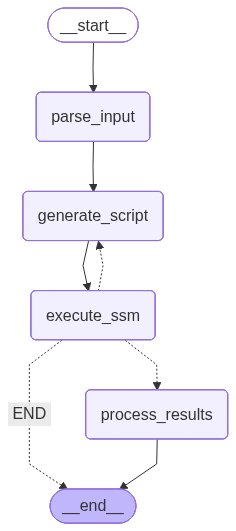

In [65]:
graph

In [66]:
sample_issue_description = '{\n    "vuln_id": "CVE-2021-44228",\n    "severity_raw": "CRITICAL",\n    "ip": "172.16.10.11",\n    "hostname": NaN,\n    "port": 8443.0,\n    "instance_id": "i-kllj",\n    "component": "log4j-core",\n    "affected_version": "2.14.1",\n    "cvss_score": 10.0,\n    "cvss_vector": "CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:C/C:H/I:H/A:H",\n    "description": "Apache Log4j2 JNDI lookups can be exploited to execute arbitrary code via a crafted string in any location where Log4j logs are enabled."\n}'

instance_id = "i-00528e32611d18c51"

In [67]:
# --- 6. Notebook Native Execution ---
# sample_issue_description = '{\n    "vuln_id": "CVE-2023-46604",\n    "severity_raw": "CRITICAL",\n    "ip": "10.20.30.48",\n    "hostname": "prod-s3-proxy.internal",\n    "port": 443.0,\n    "instance_id": "i-00528e32611d18c51",\n    "component": "activemq",\n    "affected_version": "5.15.15",\n    "cvss_score": 10.0,\n    "cvss_vector": "CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:C/C:L/I:H/A:H",\n    "description": "CVE-2023-46604: Apache ActiveMQ remote code execution vulnerability via the OpenWire p",\n    "references": "https://nvd.nist.gov/vuln/detail/CVE-2023-46604",\n    "title": "CVE-2023-46604: The Java OpenWire protocol marshaller is vulnerable to Remote Code  Execution...",\n    "fix_version": "5.15.16",\n    "published_date": "2023-10-27",\n    "epss_score": 0.99654,\n    "kev_flag": 1,\n    "exploit_exists": 1,\n    "exploit_count": 1,\n    "asset_id": "09e94a38-e94f-4e9a-88f9-8fbe892b6d47",\n    "inferred_role": "WEB",\n    "exposure_score": 0.8,\n    "environment": "PROD",\n    "cloud_type": "NONE",\n    "dependency_level": "HIGH",\n    "dependency_score": 0.75,\n    "asset_criticality_score": 0.775,\n    "first_seen": "2026-06-21 10:15:38.415002",\n    "last_seen": "2026-06-29T17:24:46.723820+00:00",\n    "priority_score": 8.94,\n    "priority_level": "HIGH",\n    "fix_available": 1\n}'

initial_state = DiscoveryAgentState(issue_description_raw=sample_issue_description, instance_id=instance_id)

# In Jupyter, we execute `await` directly in the global block without manual loop extraction
final_state = await graph.ainvoke(initial_state)

print("\n=== FINAL RECONNAISSANCE ARTIFACT SUMMARY ===")
# Look inside the nested discovery_result block
res = final_state.get("discovery_result", {})

print(f"Installation Type: {res.get('installation_type')}")
print(f"Active PIDs: {res.get('active_pids')}")
print(f"Target Jars to Fix ({len(res.get('target_jars', []))}):")
for jar in res.get('target_jars', [])[:3]:  # Print just the first few for neatness
    print(f"  - {jar}")
if len(res.get('target_jars', [])) > 3:
    print(f"  ... and {len(res.get('target_jars', [])) - 3} more.")
    
print(f"Config Files ({len(res.get('config_files', []))}):")
for cfg in res.get('config_files', []):
    print(f"  - {cfg}")

[DISCOVERY AGENT] 🧠 Mapping system location checks for 'log4j-core' (Attempt 1)...
[DISCOVERY AGENT] 🚀 Dispatching discovery mapping to target EC2: i-00528e32611d18c51
[DISCOVERY AGENT] ✅ Host-level inventory check completed successfully.

=== FINAL RECONNAISSANCE ARTIFACT SUMMARY ===
Installation Type: jar
Active PIDs: []
Target Jars to Fix (3):
  - /opt/activemq/lib/optional/log4j-core-2.20.0.jar
  - /usr/share/java/log4j-core-2.17.1.jar
  - /home/ubuntu/log4shell-lab/log4j-core-2.14.1.jar
Config Files (0):


In [73]:
import os
import re
import json
import time
import asyncio
import boto3
from typing import Optional, Dict, Any, List
from pydantic import BaseModel, Field
from dotenv import load_dotenv

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

# Optional: Resolves potential event loop conflicts in older Jupyter versions
import nest_asyncio
nest_asyncio.apply()

load_dotenv()

# --- 1. Structured Output Models ---
class DiscoveryScriptOutput(BaseModel):
    discovery_script: str = Field(
        ...,
        description=(
            "A safe, read-only bash script designed to locate the target component installation. "
            "CRITICAL PROTOCOLS:\n"
            "1. DO NOT use the 'jq' command tool or external JSON libraries anywhere in the script.\n"
            "2. DO NOT define or invoke custom bash functions (e.g., do not use functions like 'add_location()').\n"
            "3. Collect discovered paths using standard loops (e.g., 'while read -r line') and manually format "
            "the stdout output into JSON using native 'printf'.\n"
            "4. Do not wrap the script inside markdown blocks."
        )
    )
    
# --- 2. State Specification ---
class DiscoveryAgentState(BaseModel):
    issue_description_raw: str
    parsed_issue: Dict[str, Any] = {}
    instance_id: str = ""
    component_name: str = ""
    
    # Script & Execution Tracking
    discovery_script: str = ""
    stdout: str = ""
    stderr: str = ""
    status: str = ""
    
    # Retry Loop Indicators
    retry_count: int = 0
    max_retries: int = 3
    
    # Final Extracted Architecture Result
    discovery_result: Optional[Dict[str, Any]] = None
    active_pids: list = []
    target_jars: list = []
    config_files: list = []

# --- 3. Functional Graph Nodes ---
async def parse_input_node(state: DiscoveryAgentState) -> Dict[str, Any]:
    """Safely cleans and parses scanner payloads containing unquoted JavaScript tokens like NaN."""
    raw_str = state.issue_description_raw
    # Sanitize naked NaN tokens to valid JSON null entries
    sanitized_str = re.sub(r'\bNaN\b', 'null', raw_str)
    parsed_json = json.loads(sanitized_str)
    
    return {
        "parsed_issue": parsed_json,
        "component_name": parsed_json.get("component", "unknown")
    }

async def generate_discovery_script_node(state: DiscoveryAgentState) -> Dict[str, Any]:
    """Generates an explicit OS/Language/Binary path discovery shell pipeline without external dependencies."""
    llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0).with_structured_output(DiscoveryScriptOutput)
    
    system_prompt = (
        "You are an elite DevSecOps automation tool. Your singular task is to write a standalone, "
        "safe, read-only bash script that discovers where and how a specific component is installed on a Linux host.\n\n"
        "CRITICAL COMPLIANCE AND ARCHITECTURAL RULES:\n"
        "1. DO NOT use 'jq' or any external JSON CLI tools. They may not be installed on the target machine.\n"
        "2. DO NOT define or invoke shell functions (e.g., add_location()).\n"
        "3. DO NOT pass custom commands or functions to 'find -exec'.\n"
        "4. Construct the output JSON string MANUALLY using standard string concatenation and 'printf'.\n\n"
        "CRITICAL LIFECYCLE RECONNAISSANCE PROTOCOLS (PROCESS TRACKING):\n"
        "- When searching for active running processes, safely handle potential leading whitespaces from 'ps' output "
        "by leveraging standard 'while read -r pid cmd' assignments. This avoids empty PID parsing anomalies.\n"
        "- Dependencies embedded inside internal runtimes (like log4j-core running inside an active application process) "
        "will not show up explicitly in process argument strings. Therefore, after compiling target locations (e.g., jar files), "
        "the script MUST loop through discovered file paths and inspect if any active process holds an open file handle "
        "using 'fuser \"$path\"' or checking '/proc/*/fd'. If an active lock is present, elevate INSTALL_TYPE to 'process' "
        "and record the active PID location (e.g., '/proc/$pid/cmdline') into the locations list.\n\n"
        "RECOMMENDED BLUEPRINT PATTERN FOR THE BASH SCRIPT:\n"
        "```bash\n"
        "#!/bin/bash\n"
        "COMPONENT=\"target_component_name\"\n"
        "INSTALL_TYPE=\"unknown\"\n"
        "LOCATIONS=\"\"\n"
        "\n"
        "# 1. Check processes via args safely (handles leading whitespace inherently)\n"
        "while read -r pid cmd; do\n"
        "    if [ -n \"$pid\" ] && echo \"$cmd\" | grep -qi \"$COMPONENT\"; then\n"
        "        INSTALL_TYPE=\"process\"\n"
        "        loc=\"/proc/$pid/cmdline\"\n"
        "        if [ -z \"$LOCATIONS\" ]; then LOCATIONS=\"\\\"$loc\\\"\"; else LOCATIONS=\"$LOCATIONS,\\\"$loc\\\"\"; fi\n"
        "    fi\n"
        "done < <(ps -eo pid,args | tail -n +2)\n"
        "\n"
        "# 2. Perform file discovery loops (e.g., find paths)\n"
        "while read -r loc; do\n"
        "    if [ -n \"$loc\" ]; then\n"
        "        [ \"$INSTALL_TYPE\" = \"unknown\" ] && INSTALL_TYPE=\"jar\"\n"
        "        if [ -z \"$LOCATIONS\" ]; then LOCATIONS=\"\\\"$loc\\\"\"; else LOCATIONS=\"$LOCATIONS,\\\"$loc\\\"\"; fi\n"
        "        \n"
        "        # 3. Handle hidden runtime dependencies via open handle checking\n"
        "        if [ -f \"$loc\" ] && [ \"${loc##*.}\" = \"jar\" ]; then\n"
        "            pid_lock=$(fuser \"$loc\" 2>/dev/null | awk '{print $1}')\n"
        "            if [ -n \"$pid_lock\" ]; then\n"
        "                INSTALL_TYPE=\"process\"\n"
        "                proc_loc=\"/proc/$pid_lock/cmdline\"\n"
        "                LOCATIONS=\"$LOCATIONS,\\\"$proc_loc\\\"\"\n"
        "            fi\n"
        "        fi\n"
        "    fi\n"
        "done < <(find /home /var /opt /usr -name \"*$COMPONENT*\" 2>/dev/null)\n"
        "\n"
        "# 4. Print final valid JSON string to stdout\n"
        "printf '{\"installation_type\": \"%s\", \"component\": \"%s\", \"locations\": [%s]}\\n' \"$INSTALL_TYPE\" \"$COMPONENT\" \"$LOCATIONS\"\n"
        "exit 0\n"
        "```\n\n"
        "Ensure all installation checks (apt, rpm, language packages, process lists, file handlers, explicit directories) follow this pattern "
        "and properly populate the single 'LOCATIONS' comma-separated string variable without trailing commas."
    )
    
    user_prompt = f"### TARGET COMPONENT DETECTED\n{json.dumps(state.parsed_issue, indent=2)}"
    
    if state.status == "Failed":
        user_prompt += (
            f"\n\n⚠️ PREVIOUS SCRIPT EXECUTION FAILED!\n"
            f"### FAILED SCRIPT:\n{state.discovery_script}\n\n"
            f"### RUNTIME STDERR:\n{state.stderr}\n\n"
            f"### RUNTIME STDOUT:\n{state.stdout}\n\n"
            f"Please diagnose the exact failure reason and generate a fully resilient, updated discovery script matching the rules above."
        )

    print(f"[DISCOVERY AGENT] 🧠 Mapping system location checks for '{state.component_name}' (Attempt {state.retry_count + 1})...")
    response: DiscoveryScriptOutput = await llm.ainvoke([
        {"role": "system", "content": system_prompt},
        HumanMessage(content=user_prompt)
    ])
    
    return {"discovery_script": response.discovery_script}

async def execute_ssm_discovery_node(state: DiscoveryAgentState) -> Dict[str, Any]:
    """Leverages the AWS Systems Manager RunShellScript pipeline to execute discovery safely."""
    ssm_client = boto3.client('ssm')
    instance_id = state.instance_id
    script_content = state.discovery_script
    
    print(f"[DISCOVERY AGENT] 🚀 Dispatching discovery mapping to target EC2: {instance_id}")
    
    try:
        response = ssm_client.send_command(
            InstanceIds=[instance_id],
            DocumentName="AWS-RunShellScript",
            Comment=f"Vulnerability Discovery Stream: {state.component_name}",
            Parameters={"commands": [script_content]}
        )
        command_id = response['Command']['CommandId']
        
        # Await command status lifecycle transitions
        while True:
            await asyncio.sleep(2)
            invocation = ssm_client.get_command_invocation(
                CommandId=command_id,
                InstanceId=instance_id
            )
            if invocation['Status'] in ['Pending', 'InProgress', 'Delayed']:
                continue
            break
            
        stdout_capture = invocation.get('StandardOutputContent', '').strip()
        stderr_capture = invocation.get('StandardErrorContent', '').strip()
        exit_code = invocation.get('ResponseCode', 0)
        ssm_status = invocation['Status']
        
        # Normalize execution boundaries
        if ssm_status == "Success" and exit_code == 0:
            print("[DISCOVERY AGENT] ✅ Host-level inventory check completed successfully.")
            return {
                "stdout": stdout_capture,
                "stderr": stderr_capture,
                "status": "Success",
                "retry_count": state.retry_count + 1
            }
        else:
            print(f"[DISCOVERY AGENT] ❌ Target execution error encountered. Status: {ssm_status}, Exit Code: {exit_code}")
            return {
                "stdout": stdout_capture,
                "stderr": stderr_capture,
                "status": "Failed",
                "retry_count": state.retry_count + 1
            }
            
    except Exception as e:
        print(f"[DISCOVERY AGENT] 💥 Critical AWS Client Exception during SSM dispatch: {str(e)}")
        return {
            "stderr": str(e),
            "status": "Failed",
            "retry_count": state.retry_count + 1
        }

async def process_results_node(state: DiscoveryAgentState) -> Dict[str, Any]:
    """Parses, filters, and groups discovery paths to prevent remediation LLM confusion."""
    try:
        match = re.search(r'(\{.*?\})', state.stdout, re.DOTALL)
        if not match:
            return {"discovery_result": {"installation_type": "unknown", "locations": []}}
            
        raw_result = json.loads(match.group(1))
        all_locations = raw_result.get("locations", [])
        
        # Categorized lists for the remediation LLM
        primary_jars = []
        config_files = []
        running_pids = []
        
        for path in all_locations:
            # 1. Extract running process context but ignore direct proc files for editing
            if "/proc/" in path:
                pid_match = re.search(r'/proc/(\d+)', path)
                if pid_match:
                    running_pids.append(pid_match.group(1))
                continue
                
            # 2. Skip example/documentation directories entirely to reduce noise
            if "examples" in path or "share/doc" in path:
                continue
                
            # 3. Separate operational configs from executable binaries
            if path.endswith(".xml"):
                config_files.append(path)
            elif path.endswith(".jar"):
                primary_jars.append(path)

        # Build a clean, structured payload that won't confuse the next stage
        refined_result = {
            "installation_type": raw_result.get("installation_type", "unknown"),
            "component": state.component_name,
            "active_pids": list(set(running_pids)),
            "target_jars": list(set(primary_jars)),
            "config_files": list(set(config_files))
        }
        
        return {"discovery_result": refined_result}

    except Exception as e:
        return {"discovery_result": {"error": f"Filter error: {str(e)}"}}

# --- 4. Dynamic Conditional Route Engine ---
def route_execution_outcome(state: DiscoveryAgentState) -> str:
    if state.status == "Success":
        return "process_results"
    
    if state.retry_count < state.max_retries:
        print(f"[DISCOVERY AGENT] 🔄 Evaluation failed. Routing back to LLM for runtime correction loop...")
        return "generate_script"
        
    print(" [DISCOVERY AGENT] 🛑 Maximum structural retry limits exhausted. Halting discovery process.")
    return END

# --- 5. Graph Pipeline Compilation ---
def build_discovery_graph():
    builder = StateGraph(DiscoveryAgentState)
    
    builder.add_node("parse_input", parse_input_node)
    builder.add_node("generate_script", generate_discovery_script_node)
    builder.add_node("execute_ssm", execute_ssm_discovery_node)
    builder.add_node("process_results", process_results_node)
    
    builder.add_edge(START, "parse_input")
    builder.add_edge("parse_input", "generate_script")
    builder.add_edge("generate_script", "execute_ssm")
    
    builder.add_conditional_edges(
        "execute_ssm",
        route_execution_outcome,
        {
            "process_results": "process_results",
            "generate_script": "generate_script",
            "END": END
        }
    )
    builder.add_edge("process_results", END)
    
    return builder.compile()

In [79]:
graph = build_discovery_graph()

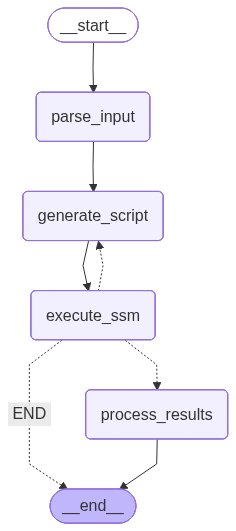

In [80]:
graph

In [81]:
# sample_issue_description = '{\n    "vuln_id": "CVE-2021-44228",\n    "severity_raw": "CRITICAL",\n    "ip": "172.16.10.11",\n    "hostname": NaN,\n    "port": 8443.0,\n    "instance_id": "i-kllj",\n    "component": "log4j-core",\n    "affected_version": "2.14.1",\n    "cvss_score": 10.0,\n    "cvss_vector": "CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:C/C:H/I:H/A:H",\n    "description": "Apache Log4j2 JNDI lookups can be exploited to execute arbitrary code via a crafted string in any location where Log4j logs are enabled."\n}'

instance_id = "i-00528e32611d18c51"

In [82]:
# --- 6. Notebook Native Execution ---
sample_issue_description = '{\n    "vuln_id": "CVE-2023-46604",\n    "severity_raw": "CRITICAL",\n    "ip": "10.20.30.48",\n    "hostname": "prod-s3-proxy.internal",\n    "port": 443.0,\n    "instance_id": "i-00528e32611d18c51",\n    "component": "activemq",\n    "affected_version": "5.15.15",\n    "cvss_score": 10.0,\n    "cvss_vector": "CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:C/C:L/I:H/A:H",\n    "description": "CVE-2023-46604: Apache ActiveMQ remote code execution vulnerability via the OpenWire p",\n    "references": "https://nvd.nist.gov/vuln/detail/CVE-2023-46604",\n    "title": "CVE-2023-46604: The Java OpenWire protocol marshaller is vulnerable to Remote Code  Execution...",\n    "fix_version": "5.15.16",\n    "published_date": "2023-10-27",\n    "epss_score": 0.99654,\n    "kev_flag": 1,\n    "exploit_exists": 1,\n    "exploit_count": 1,\n    "asset_id": "09e94a38-e94f-4e9a-88f9-8fbe892b6d47",\n    "inferred_role": "WEB",\n    "exposure_score": 0.8,\n    "environment": "PROD",\n    "cloud_type": "NONE",\n    "dependency_level": "HIGH",\n    "dependency_score": 0.75,\n    "asset_criticality_score": 0.775,\n    "first_seen": "2026-06-21 10:15:38.415002",\n    "last_seen": "2026-06-29T17:24:46.723820+00:00",\n    "priority_score": 8.94,\n    "priority_level": "HIGH",\n    "fix_available": 1\n}'

initial_state = DiscoveryAgentState(issue_description_raw=sample_issue_description, instance_id=instance_id)

# In Jupyter, we execute `await` directly in the global block without manual loop extraction
final_state = await graph.ainvoke(initial_state, instance_id = instance_id)

print("\n=== FINAL RECONNAISSANCE ARTIFACT SUMMARY ===")
# Look inside the nested discovery_result block
res = final_state.get("discovery_result", {})

print(f"Installation Type: {res.get('installation_type')}")
print(f"Active PIDs: {res.get('active_pids')}")
print(f"Target Jars to Fix ({len(res.get('target_jars', []))}):")
for jar in res.get('target_jars', [])[:3]:  # Print just the first few for neatness
    print(f"  - {jar}")
if len(res.get('target_jars', [])) > 3:
    print(f"  ... and {len(res.get('target_jars', [])) - 3} more.")
    
print(f"Config Files ({len(res.get('config_files', []))}):")
for cfg in res.get('config_files', []):
    print(f"  - {cfg}")

[DISCOVERY AGENT] 🧠 Mapping system location checks for 'activemq' (Attempt 1)...
[DISCOVERY AGENT] 🚀 Dispatching discovery mapping to target EC2: i-00528e32611d18c51
[DISCOVERY AGENT] ✅ Host-level inventory check completed successfully.

=== FINAL RECONNAISSANCE ARTIFACT SUMMARY ===
Installation Type: process
Active PIDs: ['226643', '226474']
Target Jars to Fix (98):
  - /usr/share/maven-repo/org/apache/activemq/activemq-broker/5.17.6/activemq-broker-5.17.6.jar
  - /usr/share/java/activemq-broker.jar
  - /usr/share/java/activemq-shiro.jar
  ... and 95 more.
Config Files (1):
  - /opt/activemq/conf/activemq.xml
